# Average Treatment Effect on the Treated Simulation

## Data Generating Process




In [2]:
from IPython.terminal.interactiveshell import TerminalPdb
import numpy as np
import pandas as pd
from scipy.special import expit

# 1. Define number of samples and true att
n_samples = 100
true_ate = 2.0

# 2. Generatt confounders


def groundtruth_simulate():
  X1 = np.random.normal(loc=0, scale=1, size=n_samples)
  X2 = np.random.uniform(low=-3, high=3, size=n_samples)
  X3 = np.random.normal(loc=1, scale=0.5, size=n_samples)

  # 3. Define the treatment assignment mechanism (propensity score)
  # The coefficients for confounders influence how they affect treatment assignment
  propensity_score_logit = 0.5 * X1 - 0.3 * X2 + 0.2 * X3 # Linear combination of confounders
  propensity_scores = expit(propensity_score_logit) # Apply logistic function (sigmoid)

  # Generatt binary treatment assignments (T)
  T = np.random.binomial(n=1, p=propensity_scores, size=n_samples)

  # 4. Define the outcome generation mechanism
  # Outcome Y depends on confounders, treatment T, and noise
  # The coefficient for T is the true_ate
  Y = 1 + 0.8 * X1 + 1.2 * X2 - 0.5 * X3 + true_ate * T + np.random.normal(loc=0, scale=1, size=n_samples)
  #Y = 1 + 0.8 * X1 + 1.2 * X2 - 0.5 * X3 + true_ate * T * (X1+X2+X3) + np.random.normal(loc=0, scale=1, size=n_samples)
  #TE= true_ate * (X1+X2+ X3)
  #TE = TE[T==1]
  #print("Ground Truth ATT",np.mean(TE))

  # 5. Combine into a Pandas DataFrame
  df_synthetic = pd.DataFrame({
      'X1': X1,
      'X2': X2,
      'X3': X3,
      'T': T,
      'Y': Y,
      'propensity_score': propensity_scores # Include for inspection if needed
  })
  return df_synthetic
df_synthetic = groundtruth_simulate()
print("Synthetic data generattd successfully. Displaying the first 5 rows:")
print(df_synthetic.head())

print("\nDescriptive statistics of the generattd data:")
print(df_synthetic.describe())

Synthetic data generattd successfully. Displaying the first 5 rows:
         X1        X2        X3  T         Y  propensity_score
0 -1.932758  0.022398  1.680480  0 -1.002429          0.345924
1  0.780270 -1.746122  1.608583  1  0.089349          0.774813
2  2.255435 -0.144045  0.679675  1  5.679650          0.786988
3 -0.588104 -1.312758  0.736774  0 -3.861339          0.561470
4 -0.104301  2.458043  1.094163  1  5.587023          0.361068

Descriptive statistics of the generattd data:
               X1          X2          X3           T           Y  \
count  100.000000  100.000000  100.000000  100.000000  100.000000   
mean     0.061087   -0.396158    0.945613    0.640000    1.216721   
std      1.038387    1.736504    0.502788    0.482418    2.745499   
min     -2.086592   -2.959465   -0.637572    0.000000   -5.072650   
25%     -0.630044   -1.810627    0.679215    0.000000   -0.492834   
50%      0.048378   -0.733406    0.871698    1.000000    0.840967   
75%      0.788902    1.0

In [3]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression # Import LogisticRegression

def propensity_score_estimation(df_synthetic):
  propensity_scores_estimated = np.random.rand(n_samples)

  X_confounders = df_synthetic[['X1', 'X2', 'X3']]
  T_treatment = df_synthetic['T'] # Explicitly define T_treatment
  log_reg = LogisticRegression(solver='liblinear', max_iter=1000, random_state=42)
  log_reg.fit(X_confounders, T_treatment)
  propensity_scores_estimated = log_reg.predict_proba(X_confounders)[:, 1]
  epsilon = 1e-7
  propensity_scores_estimated = np.clip(propensity_scores_estimated, epsilon, 1 - epsilon)
  return propensity_scores_estimated

propensity_scores_estimated = propensity_score_estimation(df_synthetic)

print(np.mean((propensity_scores_estimated-df_synthetic["propensity_score"]) ** 2))

0.006053066659361739


## Propensity stratification

In [7]:
def stratification(df, K=5):

    propensity_used = propensity_score_estimation(df)
    df_stratification = df.copy()

    # 1. Divide data into K strata based on propensity scores
    # Handle cases where pd.qcut might creatt fewer bins due to duplicatt edges
    df_stratification['stratum'] = pd.qcut(
        propensity_used,
        q=K,
        labels=False
    )

    stratum_atts = []
    strtum_T = []
    stratum_Ns = [] # Total observations per stratum
    stratum_variance_contributions = []

    N_total = len(df_stratification)
    N1 = len(df_stratification[df_stratification['T'] == 1])

    # Iteratt through each unique stratum
    for stratum_id in sorted(df_stratification['stratum'].unique()):
        stratum_df = df_stratification[df_stratification['stratum'] == stratum_id]

        treated_in_stratum = stratum_df[stratum_df['T'] == 1]
        control_in_stratum = stratum_df[stratum_df['T'] == 0]

        N_k = len(stratum_df) # Total observations in current stratum

        if len(treated_in_stratum) > 0 and len(control_in_stratum) > 0:
            # i. Calculatt mean outcome for treated and control groups
            mean_outcome_treated = treated_in_stratum['Y'].mean()
            mean_outcome_control = control_in_stratum['Y'].mean()

            # ii. Compute and store stratum-specific att
            stratum_att = mean_outcome_treated - mean_outcome_control
            stratum_atts.append(stratum_att)

            # iii. Store total number of observations in stratum
            stratum_Ns.append(N_k)

            # iv. Calculatt variance of outcomes for treated and control groups
            N_1k = len(treated_in_stratum)
            strtum_T.append(N_1k)
            N_0k = len(control_in_stratum)

            # Handle single observation case for variance (variance = 0 if N <= 1)
            S1k_sq = treated_in_stratum['Y'].var(ddof=1) if N_1k > 1 else 0.0
            S0k_sq = control_in_stratum['Y'].var(ddof=1) if N_0k > 1 else 0.0

            # v. Compute stratum's variance contribution term
            var_contribution_term = 0.0
            if N_1k > 0: # Ensure no division by zero
                var_contribution_term += S1k_sq / N_1k
            if N_0k > 0: # Ensure no division by zero
                var_contribution_term += S0k_sq / N_0k

            # vi. Store this variance contribution term
            stratum_variance_contributions.append(var_contribution_term)
        else:
            # If a stratum has no treated or no control units, it cannot contribute to att
            # This case will be handled by np.average ignoring it if stratum_Ns is empty
            pass

    overall_stratified_att = np.nan
    estimated_variance_stratified_att = np.nan

    if len(stratum_atts) > 0 and sum(stratum_Ns) > 0:
        # a. Calculatt overall stratified att as weighted average
        overall_stratified_att = np.average(stratum_atts, weights=strtum_T)

        # b. Calculatt the estimated variance of the stratified att
        # Using the formula: Var(att_strat) = sum_k (N_k/N)^2 * (S1k_sq/N1k + S0k_sq/N0k)
        weighted_variance_sum = 0.0
        for i in range(len(stratum_atts)):
            weight_nk_N = strtum_T[i] / N1
            weighted_variance_sum += (weight_nk_N**2) * stratum_variance_contributions[i]
            weighted_variance_sum += weight_nk_N * (stratum_atts[i] - overall_stratified_att) ** 2 / N_total
        estimated_variance_stratified_att = weighted_variance_sum

    return overall_stratified_att, estimated_variance_stratified_att


### Run Simulation


In [8]:
num_simulations = 100

stra_estimates5 = []
stra_var_estimates5 = []
stra_estimates10 = []
stra_var_estimates10 = []
stra_estimates2 = []
stra_var_estimates2 = []

for i in range(num_simulations):
    df = groundtruth_simulate()

    # simulate and estimate using IPW

    stra_est, var_est = stratification(df,2)
    stra_estimates2.append(stra_est)
    stra_var_estimates2.append(var_est)

    stra_est, var_est = stratification(df,5)
    stra_estimates5.append(stra_est)
    stra_var_estimates5.append(var_est)

    stra_est, var_est = stratification(df,10)
    stra_estimates10.append(stra_est)
    stra_var_estimates10.append(var_est)

print(f"mean of Stratified Estimate (K=2): {np.mean(stra_estimates2):.4f}" )
print(f"Variance of Stratified Estimate (K=2): {np.var(stra_estimates2):.4f}, expectation of Stratified variance: {np.mean(stra_var_estimates2):.4f}" )


print(f"mean of Stratified Estimate (K=5): {np.mean(stra_estimates5):.4f}" )
print(f"Variance of Stratified Estimate (K=5): {np.var(stra_estimates5):.4f}, expectation of Stratified variance: {np.mean(stra_var_estimates5):.4f}" )

print(f"mean of Stratified Estimate (K=10): {np.mean(stra_estimates10):.4f}" )
print(f"Variance of Stratified Estimate (K=10): {np.var(stra_estimates10):.4f}, expectation of Stratified variance: {np.mean(stra_var_estimates10):.4f}" )




mean of Stratified Estimate (K=2): 1.9002
Variance of Stratified Estimate (K=2): 0.0827, expectation of Stratified variance: 0.2754
mean of Stratified Estimate (K=5): 2.0510
Variance of Stratified Estimate (K=5): 0.1113, expectation of Stratified variance: 0.3022
mean of Stratified Estimate (K=10): 2.0630
Variance of Stratified Estimate (K=10): 0.1431, expectation of Stratified variance: 0.2668


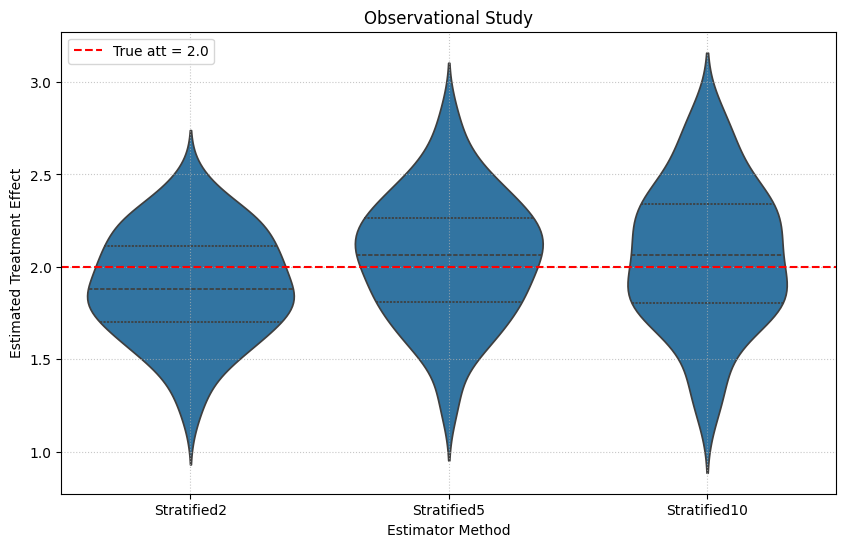

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Combine the estimates into a DataFrame for easier plotting
data = {
    'Estimator':  ['Stratified2'] * len(stra_estimates2) +  ['Stratified5'] * len(stra_estimates5) +  ['Stratified10'] * len(stra_estimates10),
    'Estimate':  stra_estimates2 + stra_estimates5 + stra_estimates10
}
df = pd.DataFrame(data)

# Creatt the violin plot
plt.figure(figsize=(10, 6))
sns.violinplot(x='Estimator', y='Estimate', data=df, inner='quartile')

# Add a horizontal dotted line for the true treatment effect
plt.axhline(y=true_ate, color='r', linestyle='--', label=f'True att = {true_ate}')

# Add labels and title
plt.title('Observational Study')
plt.xlabel('Estimator Method')
plt.ylabel('Estimated Treatment Effect')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

## Propensity-based estimator

### IPW

In [11]:
## IPW
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression # Import LogisticRegression
from sklearn.linear_model import LinearRegression # Will be needed lattr

def IPW(df):
    # 1. Get estimated propensity scores
    ps_estimated = propensity_score_estimation(df)
    # Clip ps_estimated between [0.1,0.9]
    #ps_estimated = np.clip(ps_estimated, 0.1, 0.9)


    # 2. Extract treatment (T) and outcome (Y) variables
    T = df['T'].values
    Y = df['Y'].values
    n = len(df)
    n1 = np.sum(T)

    treated_mean = np.sum(Y * T) / n1
    ipw_term_control = (Y * (1 - T)) / (1 - ps_estimated) * ps_estimated
    att_ipw = treated_mean - np.sum(ipw_term_control) /n1


    return att_ipw,None

In [13]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression # Import LogisticRegression
from sklearn.linear_model import LinearRegression # Will be needed lattr

def Hajek(df):
    # 1. Get estimated propensity scores
    ps_estimated = propensity_score_estimation(df)
    # Clip ps_estimated between [0.1,0.9]
    #ps_estimated = np.clip(ps_estimated, 0.1, 0.9)

    # 2. Extract treatment (T) and outcome (Y) variables
    T = df['T'].values
    Y = df['Y'].values
    n = len(df)
    n1 = np.sum(T)


    treated_mean = np.sum(Y * T) / n1
    ipw_term_control = (Y * (1 - T)) / (1 - ps_estimated) * ps_estimated
    att_hajek= treated_mean - np.sum(ipw_term_control) /np.sum( 1/(1 - ps_estimated) * ps_estimated * (1-T))

    return att_hajek, None

### Outcome Regression

In [14]:
#Outcome regression
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

def outcome_reg(df):
    # 1. Extract confounder variables and the outcome variable
    X_confounders = df[['X1', 'X2', 'X3']][df['T'] == 1]
    n = len(df)

    # Separatt data into treated and control groups
    treated_df = df[df['T'] == 1]
    control_df = df[df['T'] == 0]
    n1 = len(treated_df)
    n0 = len(control_df) # Get number of control units



    # 3. Fit a LinearRegression model for the control group
    model_control = LinearRegression()
    model_control.fit(control_df[['X1', 'X2', 'X3']], control_df['Y'])


    # mu_0_hat (predicted outcome if control, T=0)
    predicted_outcome_control = model_control.predict(X_confounders)

    # 5. Calculatt the att
    att_or = np.mean(treated_df['Y'] - predicted_outcome_control)


    return att_or, None

### AIPW

In [16]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression, LinearRegression # Ensure both are imported


def AIPW(df):
    # 1. Get estimated propensity scores
    ps_estimated = propensity_score_estimation(df)
    o_est = ps_estimated/(1-ps_estimated)

    # 2. Extract treatment (T), outcome (Y), and confounder variables
    X_confounders = df[['X1', 'X2', 'X3']]
    Y = df['Y'].values
    T = df['T'].values
    n = len(df)
    n1 = np.sum(T)

    treated_df = df[df['T'] == 1]
    control_df = df[df['T'] == 0]

    model_control = LinearRegression()
    model_control.fit(control_df[['X1', 'X2', 'X3']], control_df['Y'])


    mu_0_hat = model_control.predict(X_confounders)

    att_or = np.sum(T*(Y -  mu_0_hat))/n1



    eif_term_control_correction = ((1 - T) * (Y - mu_0_hat)) * o_est


    att_aipw = att_or - np.sum(eif_term_control_correction )/n1



    return att_aipw, None

## Run Simulation




In [17]:
num_simulations = 100

ipw_estimates = []
ipw_var_estimates = []
or_estimates = []
or_var_estimates = []
aipw_estimates = []
aipw_var_estimates = []
hajek_estimates = []
hajek_var_estimates = []

for i in range(num_simulations):
    df = groundtruth_simulate()

    # IPW Estimator
    att_ipw, var_ipw = IPW(df)
    ipw_estimates.append(att_ipw)


    # Outcome Regression Estimator
    att_or, var_or = outcome_reg(df)
    or_estimates.append(att_or)


    # AIPW Estimator
    att_aipw, var_aipw = AIPW(df)
    aipw_estimates.append(att_aipw)


    # Hajek Estimator
    att_hajek, var_hajek = Hajek(df)
    hajek_estimates.append(att_hajek)


print(f"--- IPW Estimator Results (n_simulations={num_simulations}) ---")
print(f"Mean of IPW att Estimates: {np.mean(ipw_estimates):.4f}")
print(f"Empirical Variance of IPW att Estimates: {np.var(ipw_estimates):.4f}")


print(f"\n--- Outcome Regression Estimator Results (n_simulations={num_simulations}) ---")
print(f"Mean of OR att Estimates: {np.mean(or_estimates):.4f}")
print(f"Empirical Variance of OR att Estimates: {np.var(or_estimates):.4f}")


print(f"\n--- AIPW Estimator Results (n_simulations={num_simulations}) ---")
print(f"Mean of AIPW att Estimates: {np.mean(aipw_estimates):.4f}")
print(f"Empirical Variance of AIPW att Estimates: {np.var(aipw_estimates):.4f}")


print(f"\n--- Hajek Estimator Results (n_simulations={num_simulations}) ---")
print(f"Mean of Hajek att Estimates: {np.mean(hajek_estimates):.4f}")
print(f"Empirical Variance of Hajek att Estimates: {np.var(hajek_estimates):.4f}")


--- IPW Estimator Results (n_simulations=100) ---
Mean of IPW att Estimates: 1.9729
Empirical Variance of IPW att Estimates: 0.0721

--- Outcome Regression Estimator Results (n_simulations=100) ---
Mean of OR att Estimates: 1.9777
Empirical Variance of OR att Estimates: 0.0387

--- AIPW Estimator Results (n_simulations=100) ---
Mean of AIPW att Estimates: 1.9778
Empirical Variance of AIPW att Estimates: 0.0443

--- Hajek Estimator Results (n_simulations=100) ---
Mean of Hajek att Estimates: 1.9654
Empirical Variance of Hajek att Estimates: 0.0741


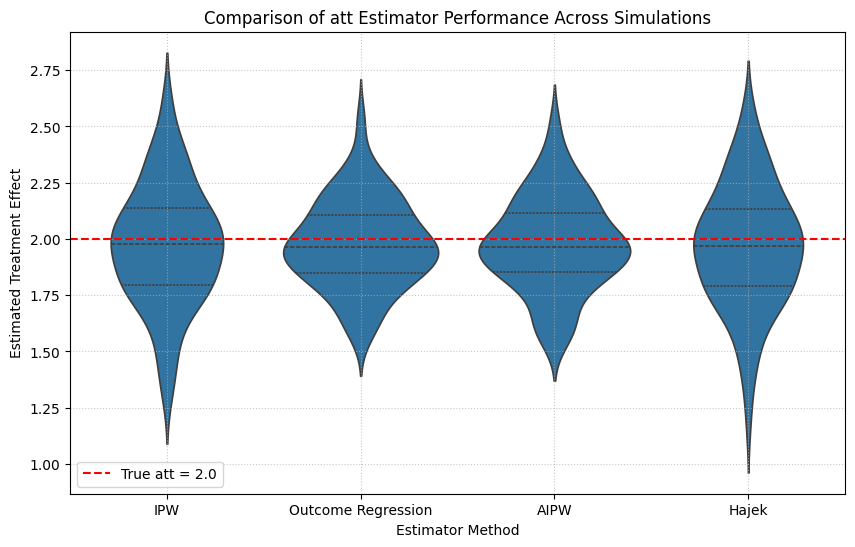

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Combine the estimates into a DataFrame for easier plotting
data = {
    'Estimator':  ['IPW'] * len(ipw_estimates) +
                  ['Outcome Regression'] * len(or_estimates) +
                  ['AIPW'] * len(aipw_estimates) +
                  ['Hajek'] * len(hajek_estimates),
    'Estimate':  ipw_estimates + or_estimates + aipw_estimates + hajek_estimates
}
df_plot = pd.DataFrame(data)

# Creatt the violin plot
plt.figure(figsize=(10, 6))
sns.violinplot(x='Estimator', y='Estimate', data=df_plot, inner='quartile')

# Add a horizontal dotted line for the true treatment effect
plt.axhline(y=true_ate, color='r', linestyle='--', label=f'True att = {true_ate}')

# Add labels and title
plt.title('Comparison of att Estimator Performance Across Simulations')
plt.xlabel('Estimator Method')
plt.ylabel('Estimated Treatment Effect')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

# Bootstrap

In [19]:
def bootstrap(method, df, num_resamples):
    att_estimates = []
    for _ in range(num_resamples):
        # Creatt a bootstrap sample (resample with replacement)
        bootstrap_sample = df.sample(n=len(df), replace=True, random_state=None) # random_state=None for different samples each time

        # Apply the provided method to the bootstrap sample
        # Assuming the method returns (att_estimate, variance_estimate)
        att_estimate, _ = method(bootstrap_sample)
        att_estimates.append(att_estimate)

    # Convert to numpy array for easier calculations
    att_estimates = np.array(att_estimates)

    # Calculatt empirical variance
    empirical_variance = np.var(att_estimates, ddof=1) # ddof=1 for sample variance

    # Calculatt 2.5% and 97.5% quantiles
    lower_quantile = np.percentile(att_estimates, 2.5)
    upper_quantile = np.percentile(att_estimates, 97.5)

    return empirical_variance, lower_quantile, upper_quantile


In [22]:
bootstrap(AIPW, df, 100)

(np.float64(0.03678664629110521),
 np.float64(1.7490163567886354),
 np.float64(2.5004654867540985))